In [13]:

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/LAB_mod_B/Project/Classification
import sys
print(sys.executable)


Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/LAB_mod_B/Project/Classification
/usr/bin/python3


# Part 0: Importing libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import os
from itertools import product
from tqdm.notebook import tqdm

from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset

# Part 1: Data

Select the zone of interest

In [15]:
sel_zone = 'IT_SICI'

In [16]:
# make directory for saving screenshots
directory_name = f'{sel_zone}_classification_plots'
try:
    os.mkdir(directory_name)
    print(f"Directory '{directory_name}' created successfully.")
except FileExistsError:
    print(f"Directory '{directory_name}' already exists.")
except PermissionError:
    print(f"Permission denied: Unable to create '{directory_name}'.")
except Exception as e:
    print(f"An error occurred: {e}")

Directory 'IT_SICI_classification_plots' created successfully.


## 1.1 Data importing and Merging

In [26]:
df_features = pd.read_csv(f'1_output/{sel_zone}_meteo_forecast_data.csv')
sel_cols = df_features.columns[(1 + 14 * 8):]
df_features = df_features[sel_cols]

df_labels = pd.read_csv(f'2_outputs/{sel_zone}_installation_detrended_actuals.csv')
df_labels['date_time'] = pd.to_datetime(df_labels['date_time'], utc= True).dt.tz_convert(None)
df_labels = df_labels.sort_values('date_time')
df_labels = df_labels.set_index('date_time')

# Define which columns to sum and which to average
sum_columns = ['solar','wind','hydro','load','detrended_solar','detrended_wind','detrended_hydro']
mean_columns = ['ratio','solar_installed','wind_installed','hydro_installed']  # example

# resample every 3h with no overlapping windows and keeping the first timestamp as index
groups = []
start_time = df_labels.index[0]

while start_time + pd.Timedelta(hours=3) <= df_labels.index[-1] + pd.Timedelta(minutes=1):
    end_time = start_time + pd.Timedelta(hours=3)
    chunk = df_labels[start_time:end_time - pd.Timedelta(seconds=1)]

    if len(chunk) == 3 and all((chunk.index == [start_time + pd.Timedelta(hours=i) for i in range(3)])):
        summed = chunk[sum_columns].sum()
        averaged = chunk[mean_columns].mean()

        combined = pd.concat([summed, averaged])
        combined.name = start_time
        groups.append(combined)

    start_time += pd.Timedelta(hours=3)

# retrieve date time info
result_df = pd.DataFrame(groups).reset_index().rename(columns={'index': 'date_time'})

In [27]:
df_labels = result_df[['solar_installed','hydro_installed','wind_installed']]
ratio = result_df[['ratio']]
df_labels_datetime = result_df[['date_time']]

# rescale the installation features
installation_scaler = StandardScaler()
installation_scaler.fit(df_labels.values)
scaled_labels = installation_scaler.transform(df_labels.values)

# merge the frames
df_labels_rescaled = pd.DataFrame({
    'scaled_solar_installed':scaled_labels[:,0],
    'scaled_hydro_installed':scaled_labels[:,1],
    'scaled_wind_installed':scaled_labels[:,2],
    'ratio':ratio.values.flatten(),
    'date_time':df_labels_datetime.values.flatten()
})
#df_labels_rescaled.head()

In [28]:
# keeping only the ones in common
df_labels_rescaled['date_time'] = pd.to_datetime(df_labels_rescaled['date_time']).dt.tz_localize(None)
df_features['date_time'] = pd.to_datetime(df_features['timestamp']).dt.tz_localize(None)
common = pd.merge(df_features, df_labels_rescaled, on='date_time', how = 'inner')
df_labels = common[df_labels_rescaled.columns]
df_features = common[df_features.columns]
print(np.shape(df_features),np.shape(df_labels))


(7994, 128) (7994, 5)


## 1.2 Define Classes based on Ratio

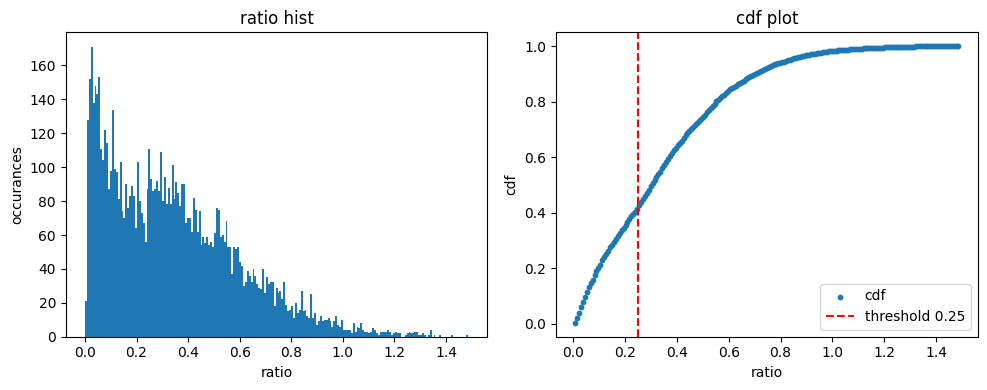

In [31]:
nbins = 200
threshold_zone = {'IT_CNOR' : 0.2, 'IT_SICI' : 0.25, 'IT_NORD' : 0.25, 'IT_CSUD' : 0.25, 'IT_SARD' : 0.5, 'IT_SUD' : 0.75, 'IT_CALA' : 0.75}
thresholds = [threshold_zone[sel_zone]]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
hist = ax[0].hist(df_labels['ratio'], bins = np.linspace(0,max(df_labels['ratio']),nbins))
ax[0].set_xlabel('ratio')
ax[0].set_ylabel('occurances')
ax[0].set_title('ratio hist')

freq = hist[0]
cdf = np.cumsum(freq)
cdf = cdf / max(cdf)
x_axis = np.linspace(0,max(df_labels['ratio']),nbins)
x_axis = x_axis[1:]
ax[1].scatter(x_axis, cdf, s = 10, label = 'cdf')
ax[1].set_xlabel('ratio')
ax[1].set_ylabel('cdf')
ax[1].set_title('cdf plot')

for threshold in thresholds:
    ax[1].axvline(x=threshold, color='r', linestyle='--', label =f'threshold {threshold}')
ax[1].legend()

plt.tight_layout()
filename = f'{directory_name}/part1.4_ratio_hist_cdf.png'
plt.savefig(filename)
plt.show()

In [32]:
class_idx = 0
new_thresholds = [0] + thresholds + [max(df_labels['ratio'])]

df_labels['class'] = np.zeros(len(df_labels.index))

print('class intervals:',new_thresholds)

# Assign class based on interval
for i in range(len(new_thresholds) - 1):
    mask = (df_labels['ratio'] > new_thresholds[i]) & (df_labels['ratio'] <= new_thresholds[i + 1])
    df_labels.loc[mask, 'class'] = class_idx
    class_idx += 1

# Check number of datapoints in each class
all_classes = np.unique(df_labels['class'])
tot = len(df_labels['class'])

for class_ in all_classes:
    occ = np.sum(df_labels['class'] == class_)
    print(f'class {int(class_)} occurs {occ} times: {occ/tot:.2%}')


class intervals: [0, 0.25, 1.4860588025448445]
class 0 occurs 3347 times: 41.87%
class 1 occurs 4647 times: 58.13%


/tmp/ipython-input-32-1236615827.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labels['class'] = np.zeros(len(df_labels.index))


## **1.3** Preprocess Features

In [34]:
# backup of timestamp for the plots
df = df_features.copy()
features = df.columns   # save features names
timestamp = pd.to_datetime(df['timestamp'])
timestamp_backup = timestamp.copy()
timestamp = df_labels['class']
timestamp_tensor = torch.tensor(timestamp, dtype = torch.float32)

to_drop = [col for col in df.columns if 'day_' in col or 'month_' in col]
#to_drop = [col for col in df.columns if col.startswith('sin') or col.startswith('cos')]       to keep day and month instead
df = df.drop(columns=to_drop + ['timestamp', 'date_time'])

print("Final input feature shape:", df.shape)
df.head()

Final input feature shape: (7994, 90)


,year_t-8,2t_t-8,solar_t-8,tp_t-8,ws_10m_t-8,ws_100m_t-8,hour_sin_t-8,hour_cos_t-8,sin_dayofyear_t-8,cos_dayofyear_t-8,...,year_t-0,2t_t-0,solar_t-0,tp_t-0,ws_10m_t-0,ws_100m_t-0,hour_sin_t-0,hour_cos_t-0,sin_dayofyear_t-0,cos_dayofyear_t-0
0,-1.226619,-0.999569,-0.840435,-0.342050,-0.190969,0.154323,-0.658723,1.520181,0.018730,1.316198,...,-1.229073,-0.771958,-0.840432,-0.322723,-0.802886,-0.830994,-1.043931,0.317057,0.043675,1.315580
1,-1.226619,-1.108632,-0.840435,-0.342050,-0.335500,-0.074293,0.271809,2.018651,0.043629,1.315582,...,-1.229073,-1.084282,-0.840432,-0.322723,-0.738270,-0.647086,-0.658517,1.520770,0.043675,1.315580
2,-1.226619,-1.080245,-0.840435,-0.342050,-0.336900,-0.173302,1.202341,1.520181,0.043629,1.315582,...,-1.229073,-1.253790,-0.840432,-0.322723,-0.796082,-0.889436,0.271956,2.019364,0.068559,1.314552
3,-1.226619,-1.184618,-0.528573,-0.346102,-0.509806,-0.482090,1.587780,0.316766,0.043629,1.315582,...,-1.229073,-1.169228,-0.840432,-0.322723,-0.314369,-0.229640,1.202429,1.520770,0.068559,1.314552
4,-1.226619,-0.448096,0.732464,-0.346102,-0.901648,-0.893205,1.202341,-0.886649,0.043629,1.315582,...,-1.229073,-1.208521,-0.545317,-0.341635,-0.413931,-0.155538,1.587843,0.317057,0.068559,1.314552


## 1.4 Dataset Setup and Split

In [35]:
# Raw input (VAE old input)
X_raw_np = df.values
scaler_input = StandardScaler()                             # rescale input
X_raw_scaled = scaler_input.fit_transform(X_raw_np)
X_raw = torch.tensor(X_raw_scaled, dtype=torch.float32)

df_extra = df_labels.drop(columns=['class', 'date_time', 'ratio'])
df_labels.head()
X_extra_np = df_extra.values
scaler_extra = StandardScaler()
X_extra_scaled = scaler_extra.fit_transform(X_extra_np)
X_extra = torch.tensor(X_extra_scaled, dtype=torch.float32)

Y = torch.tensor(df_labels['class'].values, dtype=torch.long)

print("X_raw:", X_raw.shape)
print("X_extra:", X_extra.shape)
print("Labels:", Y.shape)

X_raw: torch.Size([7994, 90])
X_extra: torch.Size([7994, 3])
Labels: torch.Size([7994])


In [36]:
class CombinedDataset(Dataset):
    def __init__(self, X_raw, X_extra, Y):
        self.X_raw = X_raw
        self.X_extra = X_extra
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X_raw[idx], self.X_extra[idx], self.Y[idx]

dataset = CombinedDataset(X_raw, X_extra, Y)
total_size = len(dataset)
train_end = int(0.7 * total_size)                             # 70% train + 15% val + 15% test
val_end = train_end + int(0.15 * total_size)

indices = list(range(total_size))
train_dataset = Subset(dataset, indices[:train_end])
val_dataset = Subset(dataset, indices[train_end:val_end])
test_dataset = Subset(dataset, indices[val_end:])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

def class_distribution(subset):
    labels = [subset[i][2].item() for i in range(len(subset))]
    return np.bincount(labels)

print("Train class distribution:", class_distribution(train_dataset))
print("Val class distribution:", class_distribution(val_dataset))
print("Test class distribution:", class_distribution(test_dataset))


Train size: 5595
Validation size: 1199
Test size: 1200
Train class distribution: [2426 3169]
Val class distribution: [415 784]
Test class distribution: [506 694]


In [37]:
# Get unique class labels and compute weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_labels = np.unique(Y.numpy())
weights = compute_class_weight(class_weight='balanced', classes=class_labels, y=Y.numpy())
weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("Class weights:", weights)

Class weights: tensor([1.1942, 0.8601])


# Part 2: Classification

## 2.1 Model Definition

In [38]:
class SimpleClassifier(nn.Module):
  def __init__(self, x_raw_dim, x_extra_dim, hidden_dims, output_dim, dropout_prob = 0.3):
    super(SimpleClassifier, self).__init__()
    input_dim = x_raw_dim + x_extra_dim

    self.net = nn.Sequential(
        nn.Linear(input_dim, hidden_dims[0]),
        nn.ReLU(),
        nn.Dropout(p=dropout_prob),
        nn.Linear(hidden_dims[0], hidden_dims[1]),
        nn.ReLU(),
        nn.Dropout(p=dropout_prob),
        nn.Linear(hidden_dims[1], output_dim)
    )

  def forward(self, x_raw, x_extra):
    x = torch.cat((x_raw, x_extra), dim=1)
    return self.net(x)

## 2.2 Training Preparation

In [39]:
x_raw_dim = X_raw.shape[1]
x_extra_dim = X_extra.shape[1]
output_dim = len(torch.unique(Y))  # number of classes
hidden_dims = [128, 64]

model = SimpleClassifier(x_raw_dim, x_extra_dim, hidden_dims, output_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


## 2.3 Training the NN

In [40]:
num_epochs = 50

# Define the search space
param_grid = {
    'hidden_dims': [[64, 32], [32,16], [16,8], [8,4]],
    'lr': [1e-4, 1e-3],
    'batch_size': [64, 128],
    'weight_decay': [1e-2, 1e-3, 1e-4],
    'dropout_prob': [0.05, 0.15, 0.3]
}

# Create all combinations of parameters
param_combinations = list(product(*param_grid.values()))

correct = 0
total = 0

# Best tracking
best_val_accuracy = 0.0
best_model = None
best_params = None
results = []

# Grid search loop
for params in tqdm(param_combinations, desc="Grid Search"):

  hidden_dims, lr, batch_size, weight_decay, dropout_prob = params
  print(f"\nTraining with: hidden_dims={hidden_dims}, lr={lr}, batch_size={batch_size}, weight_decay={weight_decay}, dropout={dropout_prob}")

  # Update loaders with batch size
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

  # Initialize model, loss, optimizer
  modelNN = SimpleClassifier(
      x_raw_dim = X_raw.shape[1],
      x_extra_dim = X_extra.shape[1],
      hidden_dims = hidden_dims,
      output_dim = len(torch.unique(Y)),
      dropout_prob=dropout_prob
  ).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(modelNN.parameters(), lr=lr, weight_decay = weight_decay)

  # Training
  for epoch in range(num_epochs):
    modelNN.train()
    for x_raw, x_extra, labels in train_loader:
      x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)

      optimizer.zero_grad()
      logits = modelNN(x_raw, x_extra)
      loss = criterion(logits, labels)
      loss.backward()
      optimizer.step()

  # Validation
  modelNN.eval()
  correct, total = 0, 0
  with torch.no_grad():
    for x_raw, x_extra, labels in val_loader:
      x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)
      logits = modelNN(x_raw, x_extra)
      _, predicted = torch.max(logits, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  val_accuracy = 100 * correct / total
  print(f"Validation Accuracy: {val_accuracy:.2f}%")

  results.append({
      'params': params,
      'val_accuracy': val_accuracy
  })

  # Save best
  if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    best_model = modelNN
    best_params = {
        'hidden_dims': hidden_dims,
        'lr': lr,
        'batch_size': batch_size,
        'weight_decay': weight_decay,
        'dropout_prob': dropout_prob
    }

print("\n Best Hyperparameters:")
print(best_params)
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")


Grid Search:   0%|          | 0/144 [00:00<?, ?it/s]


Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.01, dropout=0.05
Validation Accuracy: 91.91%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.01, dropout=0.15
Validation Accuracy: 92.16%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.01, dropout=0.3
Validation Accuracy: 90.99%

Training with: hidden_dims=[64, 32], lr=0.0001, batch_size=64, weight_decay=0.001, dropout=0.05


KeyboardInterrupt: 

# Part 3: Retraining with best params

Training Epochs:   0%|          | 0/150 [00:00<?, ?it/s]


 Final Validation Accuracy: 91.08%


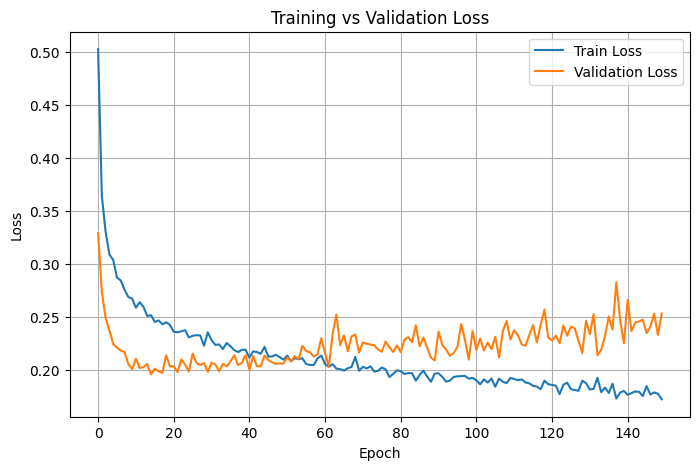

In [ ]:
num_epochs = 150
hidden_dims = best_params['hidden_dims']
lr = best_params['lr']
batch_size = best_params['batch_size']
weight_decay = best_params['weight_decay']
dropout_prob = best_params['dropout_prob']


train_dataset = Subset(dataset, indices[:train_end])
val_dataset = Subset(dataset, indices[train_end:val_end])
test_dataset = Subset(dataset, indices[val_end:])

modelNN = SimpleClassifier(
    x_raw_dim = X_raw.shape[1],
    x_extra_dim = X_extra.shape[1],
    hidden_dims = hidden_dims,
    output_dim = len(torch.unique(Y)),
    dropout_prob = dropout_prob
).to(device)

criterion = nn.CrossEntropyLoss(weight = weights)
optimizer = optim.Adam(modelNN.parameters(), lr=lr, weight_decay=weight_decay)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

NNlosses = []
val_losses = []

epoch_bar = tqdm(range(num_epochs), desc="Training Epochs")

for epoch in epoch_bar:
    modelNN.train()
    epoch_loss = 0.0

    for x_raw, x_extra, labels in train_loader:
        x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = modelNN(x_raw, x_extra)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_raw.size(0)

    avg_train_loss = epoch_loss / len(train_loader.dataset)
    NNlosses.append(avg_train_loss)

    # Validation loss
    modelNN.eval()
    val_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for x_raw, x_extra, labels in val_loader:
            x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)

            logits = modelNN(x_raw, x_extra)
            loss = criterion(logits, labels)

            val_loss += loss.item() * x_raw.size(0)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    val_accuracy = 100 * correct / total
    epoch_bar.set_postfix(train_loss=avg_train_loss, val_loss=avg_val_loss, val_acc=val_accuracy)

print(f"\n Final Validation Accuracy: {val_accuracy:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs), NNlosses, label='Train Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

filename = f'{directory_name}/NN_loss.png'
plt.savefig(filename)
plt.show()

# Part 4: Final Results

## 4.0: Time-aware accuracy

In [ ]:
def accuracy_score(y_true, y_pred):
    """
    Compute the classification accuracy.

    Parameters:
    - y_true: true labels (1D array-like or tensor)
    - y_pred: predicted labels (1D array-like or tensor)

    Returns:
    - accuracy: float (percentage of correct predictions)
    """
    # Convert to numpy if they are torch tensors
    if hasattr(y_true, 'detach'):
        y_true = y_true.detach().cpu().numpy()
    if hasattr(y_pred, 'detach'):
        y_pred = y_pred.detach().cpu().numpy()

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    correct = (y_true == y_pred).sum()
    total = len(y_true)
    return correct / total

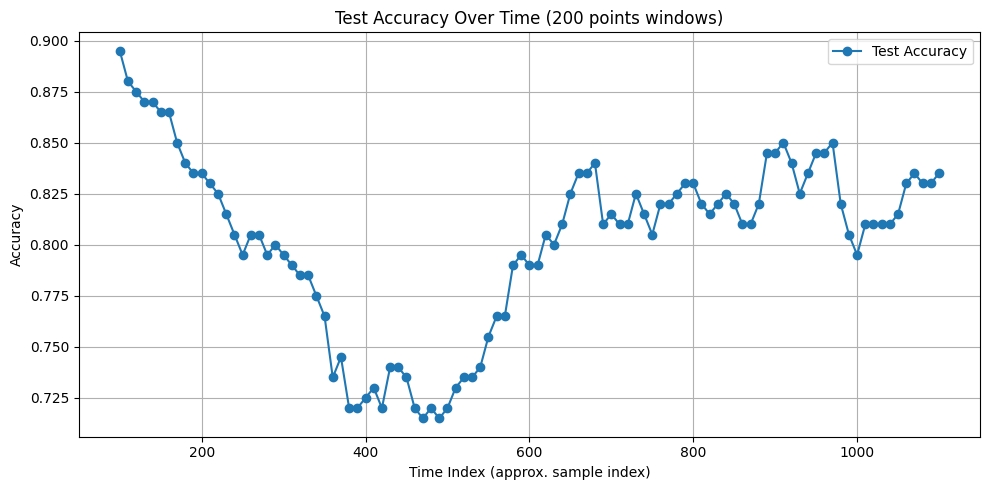

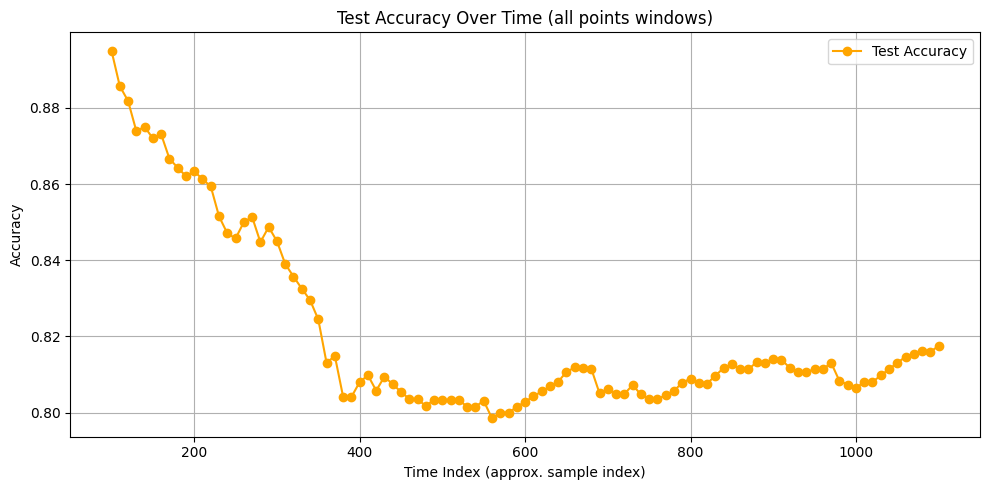

In [ ]:
modelNN.eval()  # Set model to eval mode
accuracies = []
time_indices = []

window_preds = []
window_labels = []
window_size = 200  # Adjust as needed
step_size = 10

index = 0

# Collect all validation data in order
all_preds = []
all_labels = []


with torch.no_grad():
  for x_raw, x_extra, labels in test_loader:
    x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)

    outputs = modelNN(x_raw, x_extra)
    preds = torch.argmax(outputs, dim=1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

# Now slide over the predictions and calculate accuracy
num_samples = len(all_preds)

for start in range(0, num_samples - window_size + 1, step_size):
  end = start + window_size
  preds_slice = all_preds[start:end]
  labels_slice = all_labels[start:end]

  acc = accuracy_score(labels_slice, preds_slice)
  accuracies.append(acc)
  time_indices.append(start + window_size // 2)  # midpoint

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time_indices, accuracies, marker='o', label='Test Accuracy')
plt.xlabel("Time Index (approx. sample index)")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Over Time (200 points windows)")
plt.grid(True)
plt.legend()
plt.tight_layout()
filename = f'{directory_name}/test_accuracy_200.png'
plt.savefig(filename)
plt.show()

accuracies = []
time_indices = []
for start in range(0, num_samples - window_size + 1, step_size):
  end = start + window_size
  preds_slice = all_preds[0:end]
  labels_slice = all_labels[0:end]

  acc = accuracy_score(labels_slice, preds_slice)
  accuracies.append(acc)
  time_indices.append(start + window_size // 2)  # midpoint

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time_indices, accuracies, marker='o', label='Test Accuracy', color = 'orange')
plt.xlabel("Time Index (approx. sample index)")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Over Time (all points windows)")
plt.grid(True)
plt.legend()
plt.tight_layout()
filename = f'{directory_name}/test_accuracy_tot.png'
plt.savefig(filename)
plt.show()

## 4.1 Confusion Matrix

In [ ]:
def plot_confusion_matrix(data_loader, dataset_name, class_names, directory_name):
  modelNN.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for x_raw, x_extra, labels in data_loader:
      x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)
      logits = modelNN(x_raw, x_extra)
      _, predicted = torch.max(logits, 1)
      all_preds.extend(predicted.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  cm = confusion_matrix(all_labels, all_preds)
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
  plt.figure(figsize=(5, 4))
  sns.heatmap(
      cm_normalized,
      annot=True,
      fmt=".2f",
      cmap='Blues',
      xticklabels=class_names,
      yticklabels=class_names,
      annot_kws={"size": 14}
  )
  plt.xlabel('Predicted label', fontsize=16)
  plt.ylabel('True label', fontsize=16)
  plt.title(f'{dataset_name} Confusion Matrix', fontsize=18)
  plt.xticks(fontsize=14)
  plt.yticks(fontsize=14)
  plt.tight_layout()

  filename = f'{directory_name}/conf_matrix_{dataset_name.lower()}.png'
  plt.savefig(filename)
  plt.show()

  print(f"\nClassification Report for {dataset_name} Set:")
  print(classification_report(all_labels, all_preds, target_names=[f"Class {c}" for c in class_names]))

### Confusion Matrix Plots

In [ ]:
class_labels = torch.unique(Y).tolist()
class_names = [str(int(c)) for c in class_labels] # Convert float class labels to strings

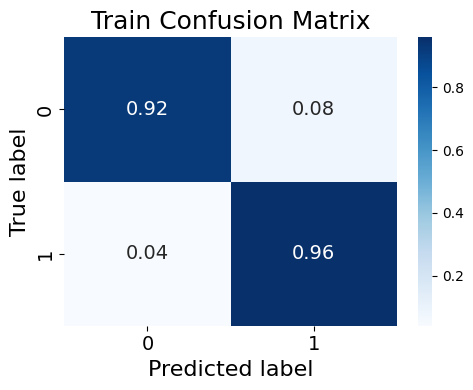


Classification Report for Train Set:
              precision    recall  f1-score   support

     Class 0       0.94      0.92      0.93      2426
     Class 1       0.94      0.96      0.95      3169

    accuracy                           0.94      5595
   macro avg       0.94      0.94      0.94      5595
weighted avg       0.94      0.94      0.94      5595



In [ ]:
plot_confusion_matrix(train_loader, "Train", class_names, directory_name)

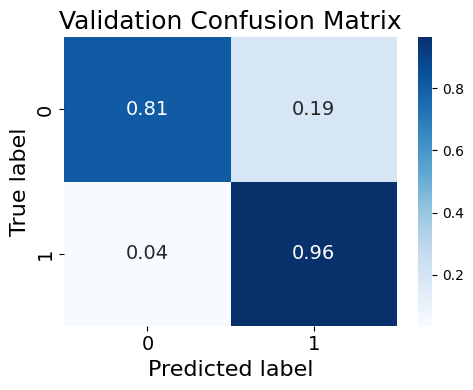


Classification Report for Validation Set:
              precision    recall  f1-score   support

     Class 0       0.92      0.81      0.86       415
     Class 1       0.91      0.96      0.93       784

    accuracy                           0.91      1199
   macro avg       0.91      0.89      0.90      1199
weighted avg       0.91      0.91      0.91      1199



In [ ]:
plot_confusion_matrix(val_loader, "Validation", class_names, directory_name)

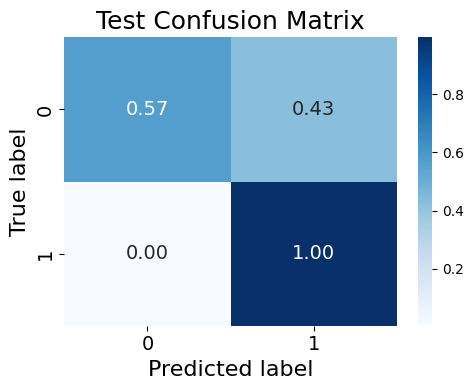


Classification Report for Test Set:
              precision    recall  f1-score   support

     Class 0       0.99      0.57      0.73       506
     Class 1       0.76      1.00      0.86       694

    accuracy                           0.82      1200
   macro avg       0.88      0.78      0.79      1200
weighted avg       0.86      0.82      0.81      1200



In [ ]:
plot_confusion_matrix(test_loader, "Test", class_names, directory_name)

## 4.2 ROC curve

In [ ]:
def plot_roc_curve(data_loader, dataset_name, directory_name):
  modelNN.eval()
  all_labels = []
  all_probs = []

  with torch.no_grad():
    for x_raw, x_extra, labels in data_loader:
      x_raw, x_extra, labels = x_raw.to(device), x_extra.to(device), labels.to(device)
      logits = modelNN(x_raw, x_extra)
      probs = torch.softmax(logits, dim=1)[:, 1]  # probs for class 1

      all_labels.extend(labels.cpu().numpy())
      all_probs.extend(probs.cpu().numpy())

  # Compute ROC curve and AUC
  fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=1)
  roc_auc = auc(fpr, tpr)

  # Plot
  plt.figure(figsize=(6, 5))
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
  plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
  plt.xlim([-0.01, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate', fontsize=14)
  plt.ylabel('True Positive Rate', fontsize=14)
  plt.title(f'{dataset_name} ROC Curve', fontsize=16)
  plt.legend(loc='lower right', fontsize=12)
  plt.grid(True)
  plt.tight_layout()

  filename = f'{directory_name}/roc_curve_{dataset_name.lower()}.png'
  plt.savefig(filename)
  plt.show()

### ROC Curve Plots

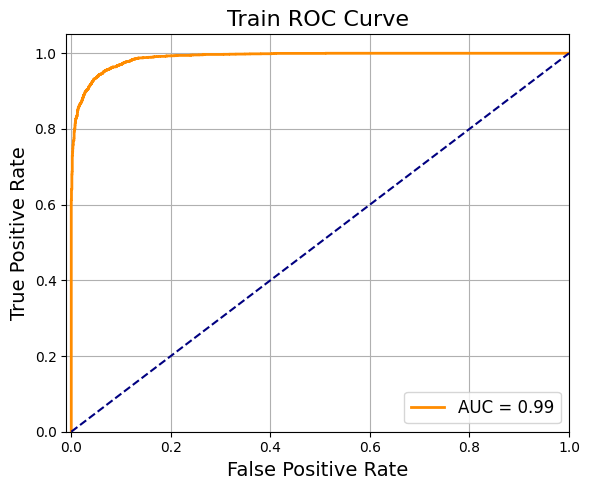

In [ ]:
plot_roc_curve(train_loader, "Train", directory_name)

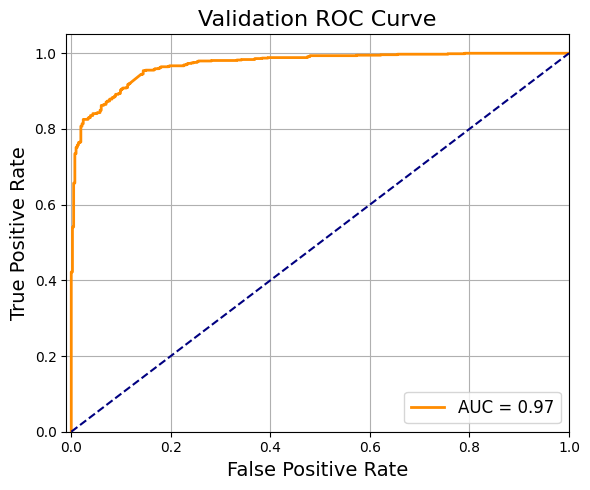

In [ ]:
plot_roc_curve(val_loader, "Validation", directory_name)

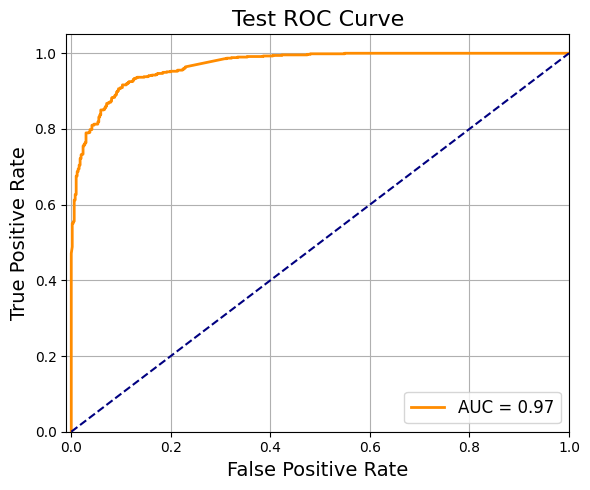

In [ ]:
plot_roc_curve(test_loader, "Test", directory_name)